# Annotating Rv Genes into gene categories of interest


In [1]:
import numpy as np
import pandas as pd
from tqdm import tqdm
import matplotlib.pyplot as plt

import seaborn as sns

%matplotlib inline

In [2]:
# https://bioframe.readthedocs.io/en/latest/guide-intervalops.html
import bioframe as bf
import bioframe.vis

#### Pandas Viewing Settings

In [3]:
pd.set_option('display.max_rows', 500)
pd.set_option('display.max_columns', 500)
pd.set_option('display.width', 1000)

In [4]:
from pycirclize import Circos

In [5]:
#%load_ext autoreload
#%autoreload 2
    
from gcutils.general import Rv_dist

# 1) Parse processed H37rv genome annotations

In [6]:
# Function to determine the gene category
def categorize_gene(row):
    gene_id = row['H37rv_GeneID']
    symbol = row['Symbol']
    
    if symbol in ListOf_Esx_Symbols:
        return "esx"
    elif gene_id in listOf_13E12_Region_RvIDs:
        return "REP13E12_Repeat"
    else:
        return row['Functional_Category']

## Import/parse processed H37rv genome annotations

In [7]:
RepoRef_Dir = "../../References"

ESX_Genes_List_TSV = f"{RepoRef_Dir}/190927_H37rv_ListOf_ESXgenes.tsv"

AnnotatedGenes_And_IntergenicRegions_RepoRef_Dir = f"{RepoRef_Dir}/201027_H37rv_AnnotatedGenes_And_IntergenicRegions"

H37Rv_GenomeAnnotations_Genes_TSV = f"{AnnotatedGenes_And_IntergenicRegions_RepoRef_Dir}/H37Rv_GenomeAnnotations.Genes.tsv"

## H37Rv Gene Annotations TSV
H37Rv_GenomeAnno_Genes_DF = pd.read_csv(H37Rv_GenomeAnnotations_Genes_TSV, sep = "\t")

RvID_To_Symbol_Dict = dict(H37Rv_GenomeAnno_Genes_DF[['H37rv_GeneID', 'Symbol']].values)
Symbol_To_FuncCat_Dict = dict(H37Rv_GenomeAnno_Genes_DF[['Symbol', 'Functional_Category']].values)

Esx_Genes_DF = pd.read_csv(ESX_Genes_List_TSV, sep = '\t')
ListOf_Esx_Symbols = list(Esx_Genes_DF["symbol"].values)

listOf_PEPPE_Symbols = list( H37Rv_GenomeAnno_Genes_DF.query(" Functional_Category == 'PE/PPE' ")["Symbol"].values )
listOf_13E12_Region_RvIDs = ["Rv0094c", "Rv0095c", "Rv0393", "Rv0397", "Rv1572c", "Rv1572c", "Rv1128c", "Rv1148c", "Rv1587c", "Rv1588c", "Rv1702c", "Rv1945", "Rv2100", "Rv3466", "Rv3467"]

H37Rv_GenomeAnno_Genes_DF['Gene_Cat_V2'] = H37Rv_GenomeAnno_Genes_DF.apply(categorize_gene, axis=1)

# Add Middle and length to the annotations TSV
H37Rv_GenomeAnno_Genes_DF["Middle"] = (H37Rv_GenomeAnno_Genes_DF["Start"] + H37Rv_GenomeAnno_Genes_DF["End"]) / 2
H37Rv_GenomeAnno_Genes_DF["Length"]  = H37Rv_GenomeAnno_Genes_DF["End"] - H37Rv_GenomeAnno_Genes_DF["Start"]        


In [8]:
H37Rv_GenomeAnno_Genes_DF.head()

,Chrom,Start,End,Strand,H37rv_GeneID,Symbol,Feature,Functional_Category,Is_Pseudogene,Product,PEandPPE_Subfamily,ExcludedGroup_Category,Gene_Cat_V2,Middle,Length
0,NC_000962.3,0,1524,+,Rv0001,dnaA,CDS,information pathways,No,Chromosomal replication initiator protein DnaA,NaN,NotExcluded,information pathways,762.0,1524
1,NC_000962.3,2051,3260,+,Rv0002,dnaN,CDS,information pathways,No,DNA polymerase III (beta chain) DnaN (DNA nucl...,NaN,NotExcluded,information pathways,2655.5,1209
2,NC_000962.3,3279,4437,+,Rv0003,recF,CDS,information pathways,No,DNA replication and repair protein RecF (singl...,NaN,NotExcluded,information pathways,3858.0,1158
3,NC_000962.3,4433,4997,+,Rv0004,Rv0004,CDS,conserved hypotheticals,No,Conserved hypothetical protein,NaN,NotExcluded,conserved hypotheticals,4715.0,564
4,NC_000962.3,5239,7267,+,Rv0005,gyrB,CDS,information pathways,No,DNA gyrase (subunit B) GyrB (DNA topoisomerase...,NaN,NotExcluded,information pathways,6253.0,2028


In [9]:
H37Rv_GenomeAnno_Genes_DF["Gene_Cat_V2"].value_counts().sum()

4079

In [10]:
H37Rv_GenomeAnno_Genes_DF["Gene_Cat_V2"].value_counts()

Gene_Cat_V2
conserved hypotheticals                    1042
intermediary metabolism and respiration     936
cell wall and cell processes                749
lipid metabolism                            272
information pathways                        242
virulence, detoxification, adaptation       239
regulatory proteins                         198
PE/PPE                                      168
insertion seqs and phages                   133
stable RNAs                                  48
esx                                          23
unknown                                      15
REP13E12_Repeat                              14
Name: count, dtype: int64

In [11]:
len(H37Rv_GenomeAnno_Genes_DF["Gene_Cat_V2"].value_counts())

13

In [12]:

def plot_gene_category_distribution(df, column='Gene_Cat_V2'):

    # List of all possible categories
    all_categories = ["esx", "PE/PPE", "REP13E12_Repeat", "conserved hypotheticals", "intermediary metabolism and respiration",
    "cell wall and cell processes", "lipid metabolism", "information pathways",
    "virulence, detoxification, adaptation", "regulatory proteins", 
    "insertion seqs and phages", "stable RNAs",  "unknown"]
    
    # Get value counts
    gene_category_counts = df[column].value_counts()
    
    # Reindex to include all categories with 0 count for missing ones
    gene_category_counts = gene_category_counts.reindex(all_categories, fill_value=0)
    
    # Create the bar plot
    plt.figure(figsize=(4, 4))
    bars = plt.barh(gene_category_counts.index, gene_category_counts.values, color='skyblue')
    plt.xlabel('Counts')
    plt.ylabel('Gene Category')
    plt.title('Distribution of Gene Categories')
    plt.gca().invert_yaxis()
    sns.despine()

    # Annotate bars with counts
    for bar in bars:
        width = bar.get_width()
        plt.text(width, bar.get_y() + bar.get_height() / 2, str(width), ha='left', va='center')

    plt.show()


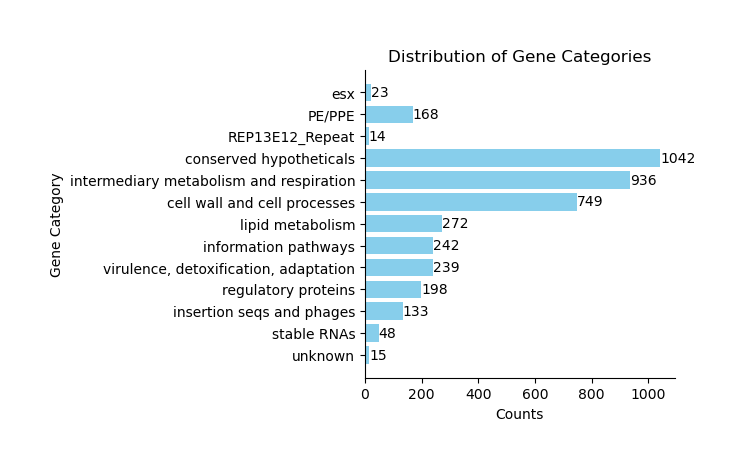

In [13]:
# Example usage with your dataframe
plot_gene_category_distribution(H37Rv_GenomeAnno_Genes_DF)

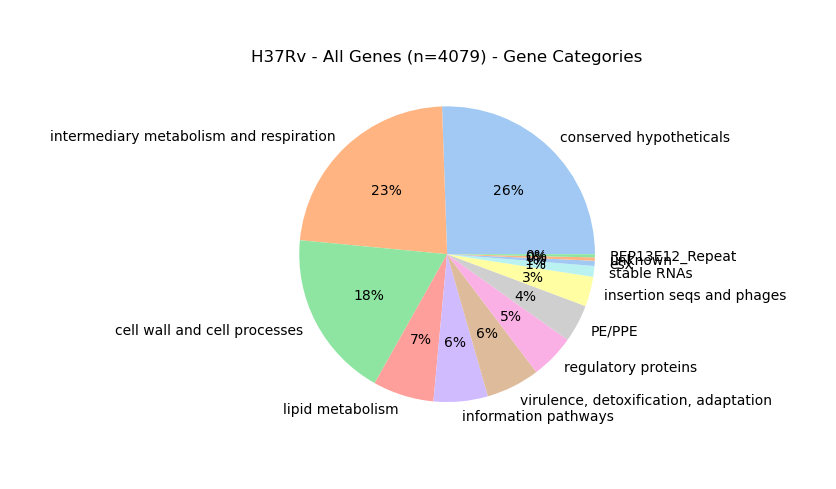

In [14]:
# https://www.statology.org/seaborn-pie-chart/

#define data
data = H37Rv_GenomeAnno_Genes_DF["Gene_Cat_V2"].value_counts().values
labels = H37Rv_GenomeAnno_Genes_DF["Gene_Cat_V2"].value_counts().index

#define Seaborn color palette to use
colors = sns.color_palette('pastel')[0:10]

#create pie chart
plt.title("H37Rv - All Genes (n=4079) - Gene Categories")
plt.pie(data, labels = labels, colors = colors, autopct='%.0f%%')
plt.show()


## Output Annotated gene categories w/ additional V2 label columns

In [15]:
H37Rv_GenomeAnnotations_Genes_V2_TSV = f"{AnnotatedGenes_And_IntergenicRegions_RepoRef_Dir}/H37Rv_GenomeAnnotations.Genes.V2.tsv"


In [16]:
H37Rv_GenomeAnno_Genes_DF.to_csv(H37Rv_GenomeAnnotations_Genes_V2_TSV,
                                 sep = "\t", index=False)

In [17]:
!head -n 2 $H37Rv_GenomeAnnotations_Genes_V2_TSV

Chrom	Start	End	Strand	H37rv_GeneID	Symbol	Feature	Functional_Category	Is_Pseudogene	Product	PEandPPE_Subfamily	ExcludedGroup_Category	Gene_Cat_V2	Middle	Length
NC_000962.3	0	1524	+	Rv0001	dnaA	CDS	information pathways	No	Chromosomal replication initiator protein DnaA		NotExcluded	information pathways	762.0	1524


In [18]:
H37Rv_GenomeAnno_Genes_DF["Functional_Category"].value_counts()

Functional_Category
conserved hypotheticals                    1042
intermediary metabolism and respiration     936
cell wall and cell processes                772
lipid metabolism                            272
information pathways                        242
virulence, detoxification, adaptation       239
regulatory proteins                         198
PE/PPE                                      168
insertion seqs and phages                   147
stable RNAs                                  48
unknown                                      15
Name: count, dtype: int64

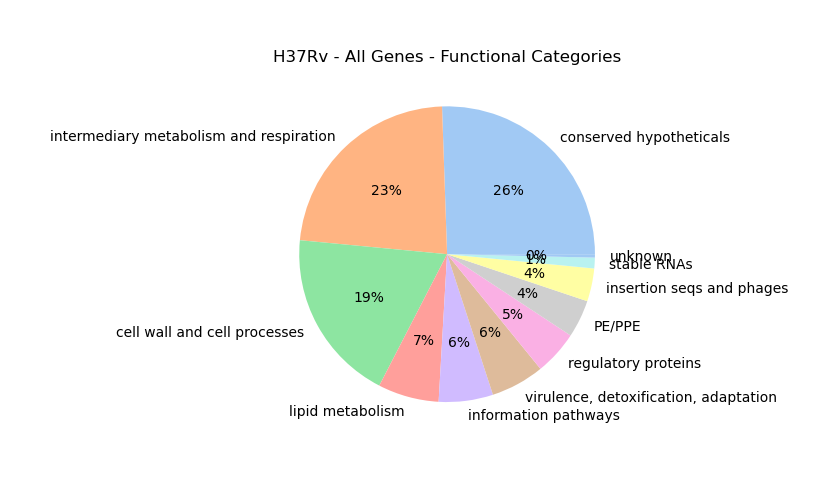

In [19]:
# https://www.statology.org/seaborn-pie-chart/

#define data
data = H37Rv_GenomeAnno_Genes_DF["Functional_Category"].value_counts().values
labels = H37Rv_GenomeAnno_Genes_DF["Functional_Category"].value_counts().index

#define Seaborn color palette to use
colors = sns.color_palette('pastel')[0:10]

#create pie chart
plt.title("H37Rv - All Genes - Functional Categories")
plt.pie(data, labels = labels, colors = colors, autopct='%.0f%%')
plt.show()
